# **Project Name**    -
### Shopper Spectrum: Customer Segmentation and Product Recommendation in E-Commerce



##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual
##### Team Member 1 -Yamini


# **Project Summary -**

This project focuses on customer segmentation and product recommendation in the e-commerce domain. The objective is to analyze customer purchasing behavior using transaction data and identify meaningful customer groups for targeted marketing. The dataset contains transaction details such as customer ID, product information, quantity purchased, invoice date, and price.
The project begins with data preprocessing, including handling missing values, removing cancelled transactions, and filtering invalid records. Exploratory Data Analysis (EDA) is performed to understand sales trends, customer behavior, top-selling products, and country-wise transaction patterns.

To segment customers, RFM (Recency, Frequency, Monetary) features are generated. These features help measure how recently a customer purchased, how often they purchase, and how much they spend. After scaling the RFM values, three clustering algorithms are implemented and compared: K-Means, Hierarchical Clustering, and GMM. Model performance is evaluated using metrics such as Silhouette Score and cluster interpretability. The best-performing model is selected for deployment.

The project also includes a product recommendation system using Item-Based Collaborative Filtering. Product similarity is calculated using Cosine Similarity on customer purchase history. When a user enters a product name, the system recommends similar products based on purchasing patterns.
Finally, a Streamlit application is developed with two modules: Customer Segmentation and Product Recommendation. The application allows users to predict customer segments and receive product recommendations in real time.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The global e-commerce industry generates massive amounts of transaction data every day, providing valuable insights into customer purchasing behavior. However, identifying meaningful customer segments and recommending relevant products from this data remains a challenge. Businesses need effective methods to understand customer preferences, improve customer retention, and increase sales through personalized experiences.

This project aims to analyze e-commerce transaction data to uncover customer purchase patterns using Recency, Frequency, and Monetary (RFM) analysis. Customer segmentation is performed using clustering techniques such as K-Means, Hierarchical Clustering, and GMM to group customers with similar purchasing behaviors. Additionally, a product recommendation system is developed using Item-Based Collaborative Filtering and Cosine Similarity to suggest relevant products based on historical purchase patterns.

The final solution helps businesses identify high-value customers, detect at-risk customers, improve targeted marketing campaigns, and provide personalized product recommendations through an interactive Streamlit application.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [3]:
# Load Dataset
import pandas as pd

df = pd.read_csv("online_retail.csv", encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


### Dataset First View

In [4]:
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
99986,544795,22613,PACK OF 20 SPACEBOY NAPKINS,1,2023-02-23 13:21:00,0.85,15858.0,United Kingdom
541849,581580,22894,TABLECLOTH RED APPLES DESIGN,2,2023-12-09 12:20:00,9.95,12748.0,United Kingdom
459427,575875,22376,AIRLINE BAG VINTAGE JET SET WHITE,1,2023-11-11 13:06:00,8.29,NaN,United Kingdom
373183,569263,23412,HEART MIRROR ANTIQUE WHITE,16,2023-10-03 11:37:00,4.98,18102.0,United Kingdom
488744,577850,21530,DAIRY MAID TOASTRACK,18,2023-11-22 11:04:00,0.79,14911.0,EIRE


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count

In [6]:
df.shape

(541909, 8)

### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(5268)

#### Missing Values/Null Values

In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

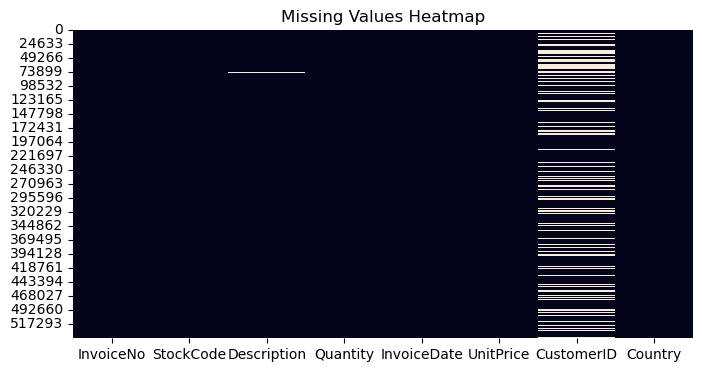

In [10]:
# Visualizing the missing values
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset contains 541,909 transaction records and 8 features related to online retail sales. It includes customer information, product details, quantity purchased, invoice dates, prices, and country information. The dataset contains 5,268 duplicate records. Missing values were found in the Description column (1,454) and CustomerID column (135,080), which is clearly visible in the missing value heatmap. Most variables are complete and suitable for customer segmentation and product recommendation analysis after proper data cleaning and preprocessing.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [12]:
# Dataset Describe
df. describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Variables Description

InvoiceNo: Unique invoice number for each transaction.
StockCode: Unique code assigned to each product.
Description: Name or description of the product.
Quantity: Number of units purchased.
InvoiceDate: Date and time when the transaction occurred.
UnitPrice: Price of a single product unit.
CustomerID: Unique identifier for each customer.
Country: Country from which the customer made the purchase.

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Write your code to make your dataset analysis ready.
# Create a copy
df_clean = df.copy()

# Remove duplicate records
df_clean = df_clean.drop_duplicates()

# Remove rows with missing CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove rows with missing Description
df_clean = df_clean.dropna(subset=['Description'])

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Remove cancelled/returned transactions
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

print("Shape after cleaning:", df_clean.shape)

Shape after cleaning: (392692, 8)


### What all manipulations have you done and insights you found?

Data Manipulations Performed:

1. Removed 5,268 duplicate records.
2. Removed rows with missing CustomerID values.
3. Removed rows with missing Description values.
4. Converted InvoiceDate from object datatype to datetime format.
5. Removed cancelled and returned transactions by filtering negative Quantity and UnitPrice values.

Insights Found:

- The original dataset contained 541,909 records.
- After cleaning, 392,692 valid records remained.
- CustomerID had the highest number of missing values.
- Negative quantities and prices indicated product returns or cancellations.
- The cleaned dataset better represents actual customer purchasing behavior and is suitable for customer segmentation and recommendation analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Top 10 Countries by Revenue

In [15]:
# Revenue = Quantity × UnitPrice
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

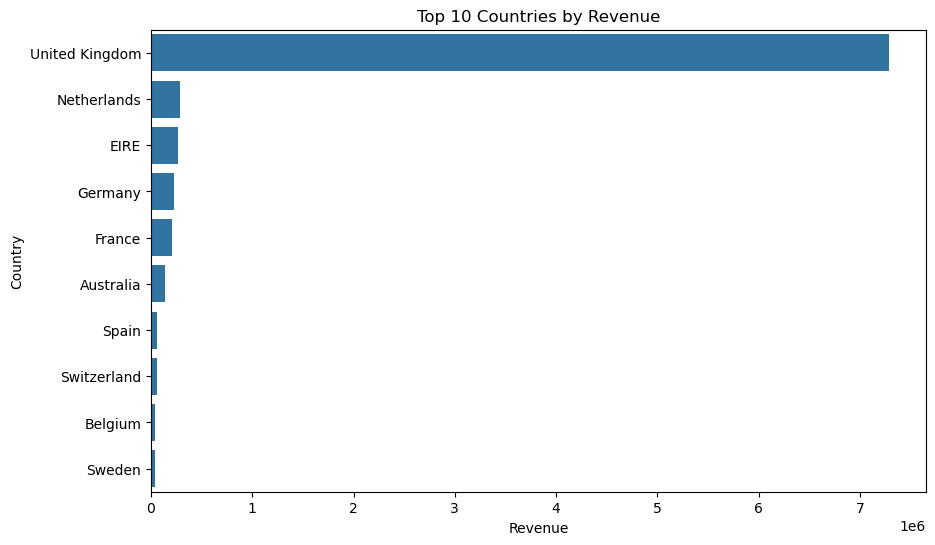

In [16]:
country_revenue = (
    df_clean.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=country_revenue.values,
    y=country_revenue.index
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was chosen because it clearly compares revenue generated by different countries and helps identify the top-performing markets.

##### 2. What is/are the insight(s) found from the chart?

The United Kingdom generates significantly higher revenue than all other countries. Netherlands, EIRE, Germany, and France are the next highest contributors, but their revenue is much lower compared to the United Kingdom. This indicates that the business heavily depends on the UK market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The company can prioritize marketing, inventory management, and customer retention efforts in high-revenue countries such as the United Kingdom and Netherlands. However, the chart also reveals a business risk because a large portion of revenue comes from a single country. Expanding sales in other countries can reduce dependency and improve long-term business stability.

 #### Chart - 2 Top 10 Products by Revenue

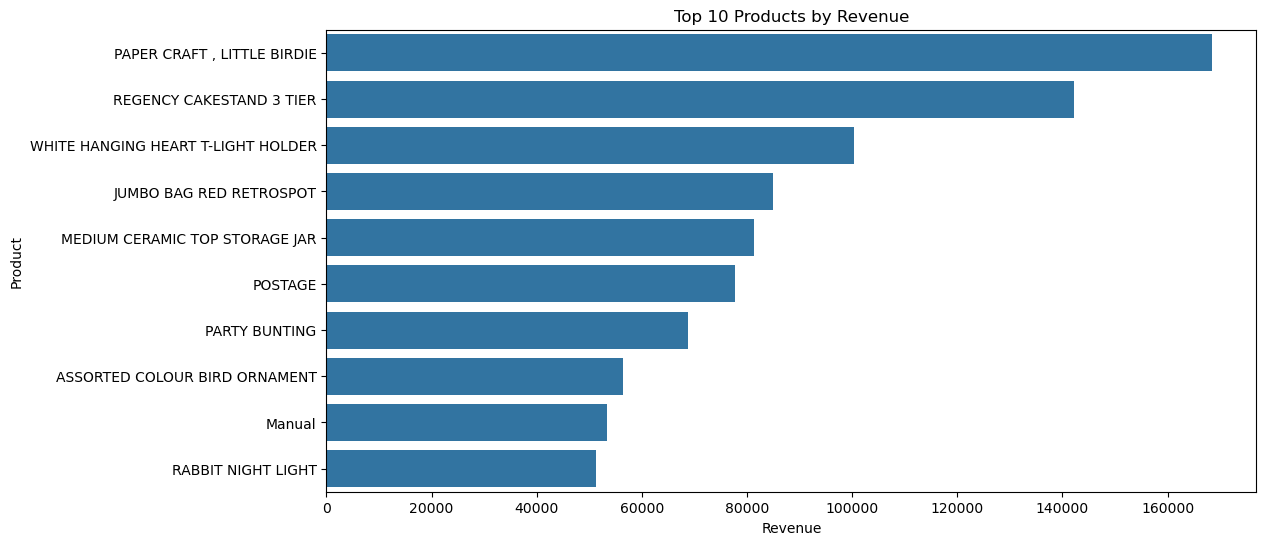

In [17]:
# Top 10 Products by Revenue

product_revenue = (
    df_clean.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=product_revenue.values,
    y=product_revenue.index
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because it effectively compares the revenue generated by different products and highlights the best-selling products in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The products PAPER CRAFT, LITTLE BIRDIE and REGENCY CAKESTAND 3 TIER generate the highest revenue among all products. A small number of products contribute a significant portion of total sales revenue, indicating that customer demand is concentrated around these products.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The company can maintain sufficient inventory for high-revenue products, improve promotional strategies around popular items, and reduce stock-out situations. The business should also analyze why these products perform well and apply similar strategies to lower-performing products. This can increase overall revenue and customer satisfaction.

#### Chart - 3 Monthly Revenue Trend 

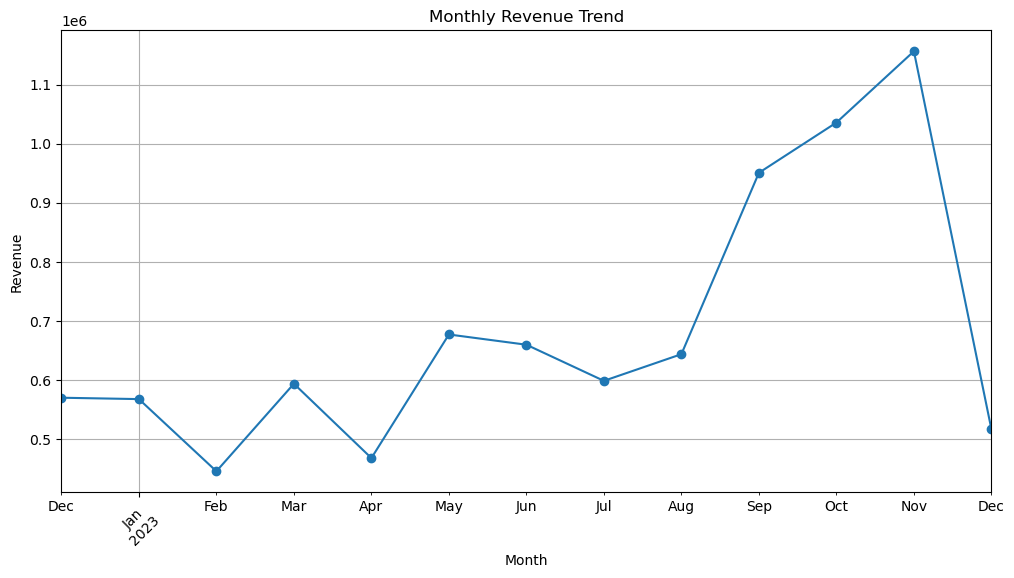

In [18]:
# Create Month-Year column
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')

monthly_revenue = (
    df_clean.groupby('Month')['Revenue']
    .sum()
)

plt.figure(figsize=(12,6))
monthly_revenue.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen because it is the best way to visualize revenue trends over time. It helps identify monthly growth, declines, seasonal patterns, and overall business performance.

##### 2. What is/are the insight(s) found from the chart?

Revenue fluctuates throughout the year, showing both growth and decline periods.

Revenue starts increasing significantly from September onwards.

The highest revenue is observed during November, indicating strong customer demand during the holiday/festive season.

February and April show comparatively lower revenue, suggesting slower sales periods.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The business can prepare inventory, marketing campaigns, and staffing based on high-demand months such as September to November. Revenue dips during February and April indicate opportunities for promotions and discounts to boost sales. Understanding these trends helps improve forecasting, customer targeting, and overall profitability.

#### Chart - 4 Revenue Distribution

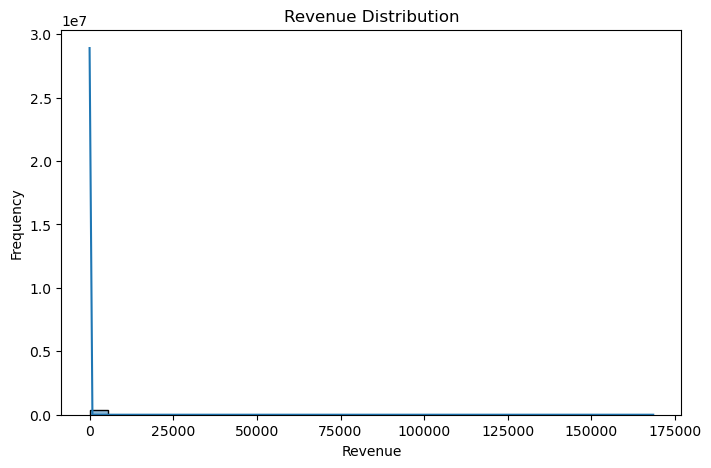

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Revenue'], bins=30, kde=True)
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was chosen because it effectively shows the distribution of revenue across all transactions. It helps identify whether revenue is concentrated in a particular range and highlights the presence of outliers.

##### 2. What is/are the insight(s) found from the chart?

Most transactions generate relatively low revenue, as shown by the high concentration of values near zero.

The distribution is highly right-skewed, indicating a few transactions generate exceptionally high revenue.

There are significant revenue outliers reaching up to around 175,000.

A small number of high-value purchases contribute disproportionately to total revenue.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The business can identify and target high-value customers who contribute a large share of revenue. Marketing campaigns, loyalty programs, and personalized recommendations can be designed for these customers. The presence of extreme outliers also suggests monitoring bulk purchases and premium products to maximize profitability. Understanding revenue distribution helps improve pricing, inventory planning, and customer segmentation.

#### Chart - 5 Revenue Share by Top 5 Countries

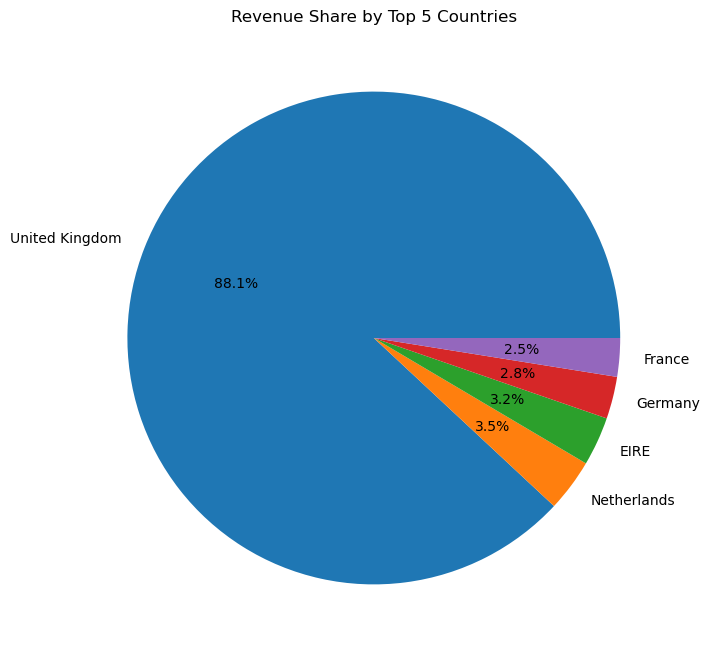

In [20]:
country_revenue = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,8))
plt.pie(country_revenue, labels=country_revenue.index, autopct='%1.1f%%')
plt.title('Revenue Share by Top 5 Countries')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart was chosen because it clearly shows the percentage contribution of each country to total revenue. It is useful for understanding market share and identifying the most important revenue-generating regions.

##### 2. What is/are the insight(s) found from the chart?

The United Kingdom contributes 88.1% of the total revenue, making it the dominant market.

The Netherlands (3.5%), EIRE (3.2%), Germany (2.8%), and France (2.5%) contribute relatively small shares.


Revenue is highly concentrated in one country rather than being evenly distributed.

The business has limited revenue diversification across international markets.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The company should continue strengthening customer retention and sales efforts in the United Kingdom since it is the primary revenue source. However, heavy dependence on a single market creates business risk. Expanding marketing campaigns and customer acquisition efforts in countries such as the Netherlands, Germany, France, and EIRE can diversify revenue streams and support sustainable long-term growth.

#### Chart - 6 Quantity vs Revenue

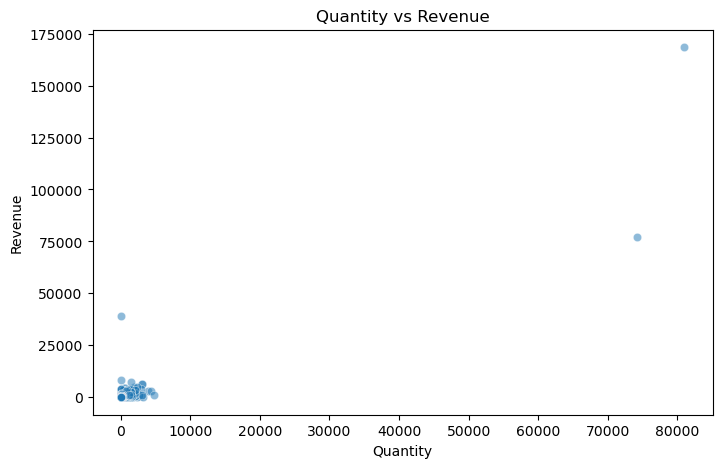

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean,
                x='Quantity',
                y='Revenue',
                alpha=0.5)

plt.title('Quantity vs Revenue')
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to analyze the relationship between two numerical variables. It helps identify trends, correlations, and outliers between Quantity sold and Revenue generated.

##### 2. What is/are the insight(s) found from the chart?

Most transactions involve low quantities and generate relatively low revenue.

A positive relationship exists between Quantity and Revenue; larger quantities generally result in higher revenue.

A few extreme outliers with very high quantities generate exceptionally high revenue.

The data is highly skewed, with most sales concentrated in smaller orders.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps identify bulk purchase patterns and high-value transactions. Businesses can target customers who make large purchases and create volume-based discounts or promotions to increase revenue. Monitoring outliers can also help identify key customers and profitable sales opportunities.

#### Chart - 7 Orders Share by Top 5 Countries

In [22]:
# Top 5 countries by number of orders

orders_country = (
    df_clean.groupby('Country')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
    .head(5)
)

print(orders_country)

Country
United Kingdom    16646
Germany             457
France              389
EIRE                260
Belgium              98
Name: InvoiceNo, dtype: int64


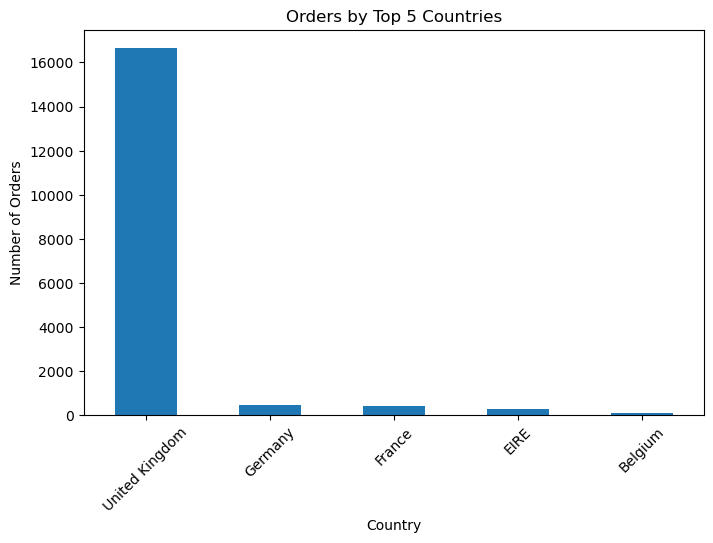

In [23]:
# Chart 7 - Orders Share by Top 5 Countries

orders_country.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Orders by Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing the number of orders across different countries. It clearly highlights which countries contribute the most orders and makes comparison easier than a pie chart.

##### 2. What is/are the insight(s) found from the chart?

The United Kingdom generates the highest number of orders by a very large margin.

Germany, France, EIRE, and Belgium contribute significantly fewer orders.

The order volume is highly concentrated in one country (United Kingdom).

There is a substantial gap between the UK and other countries in customer activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The company can continue strengthening its presence in the United Kingdom while exploring growth opportunities in Germany, France, EIRE, and Belgium. Dependence on a single country may be risky, so expanding sales in other countries can reduce business risk and increase long-term revenue growth.

#### Chart - 8 Quantity Distribution

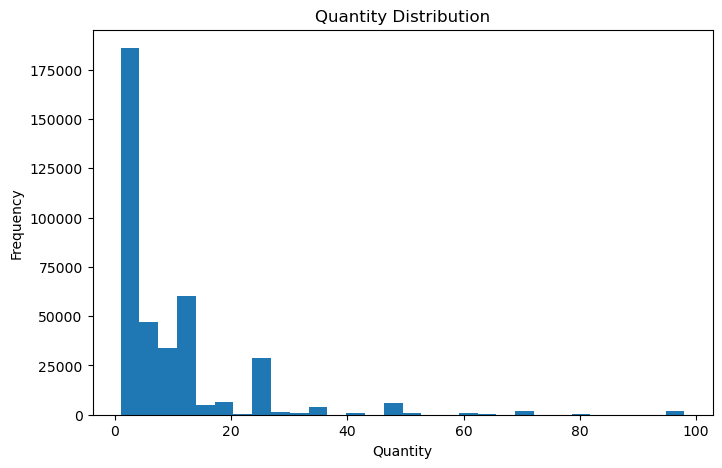

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df_clean[df_clean['Quantity'] < 100]['Quantity'], bins=30)

plt.title('Quantity Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is ideal for visualizing the distribution of quantity values. It helps identify the most common order quantities, data spread, and potential outliers.

##### 2. What is/are the insight(s) found from the chart?

Most orders contain low quantities (mainly between 1 and 10 units).

The distribution is positively skewed (right-skewed), meaning a few transactions have very high quantities.

Bulk purchases are relatively rare compared to regular customer orders.


Several outliers exist at higher quantity levels, indicating occasional large-volume transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding common order quantities helps improve inventory planning and stock management. The business can identify bulk-purchasing customers for special offers and ensure sufficient stock for frequently ordered quantity ranges, leading to better customer satisfaction and revenue growth.

#### Chart - 9 Unit Price Distribution

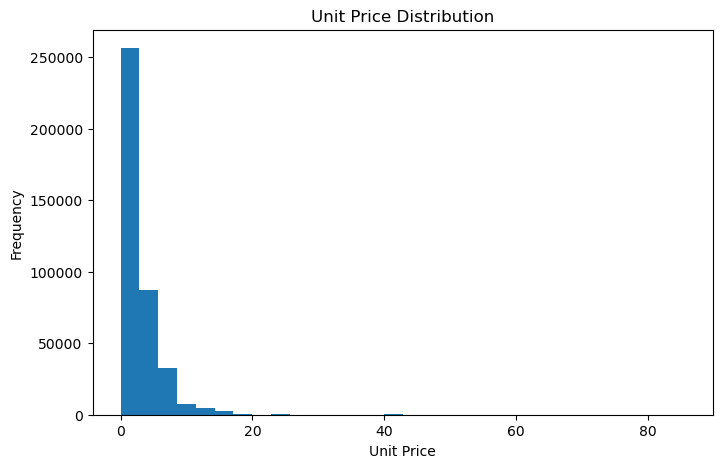

In [25]:
plt.figure(figsize=(8,5))
plt.hist(df_clean[df_clean['UnitPrice'] < 100]['UnitPrice'], bins=30)

plt.title('Unit Price Distribution')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is useful for understanding the distribution of unit prices across products. It helps identify common price ranges, pricing patterns, and outliers.

##### 2. What is/are the insight(s) found from the chart?

Most products are concentrated in the low-price range (below 10 units).

The distribution is highly right-skewed, meaning only a few products have high prices.

Low-priced products dominate the transactions and customer purchases.

There are some high-priced outliers, indicating premium or specialty products.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The business can focus on the most popular price ranges to maximize sales while also identifying premium products for higher profit margins. Understanding price distribution helps improve pricing strategy, product positioning, and inventory planning, leading to better revenue generation.

#### Chart - 10 CustomerID vs Revenue

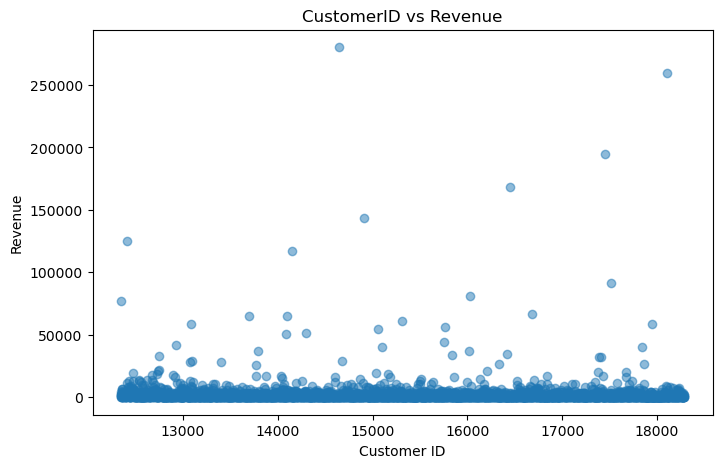

In [26]:
customer_revenue = df_clean.groupby('CustomerID')['Revenue'].sum().reset_index()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(customer_revenue['CustomerID'],
            customer_revenue['Revenue'],
            alpha=0.5)

plt.title('CustomerID vs Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to analyze the relationship between Customer ID and Revenue. It helps identify customer spending patterns and detect high-value customers.

##### 2. What is/are the insight(s) found from the chart?

Most customers generate low to moderate revenue.
A few customers contribute exceptionally high revenue, appearing as outliers.
Revenue is not evenly distributed among customers.
Some customers are highly valuable and contribute significantly to total sales.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The business can identify high-value customers and target them with loyalty programs, personalized offers, and retention strategies. This can improve customer satisfaction and increase overall revenue. The presence of a few high-revenue customers also suggests the need to reduce dependency on a small customer group by expanding the customer base.

#### Chart - 11 Quantity vs UnitPrice

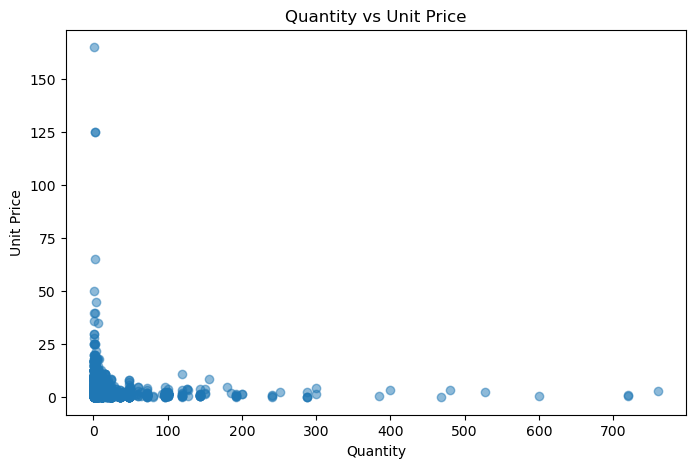

In [27]:
sample_df = df_clean.sample(5000, random_state=42)

plt.figure(figsize=(8,5))
plt.scatter(sample_df['Quantity'], sample_df['UnitPrice'], alpha=0.5)

plt.title('Quantity vs Unit Price')
plt.xlabel('Quantity')
plt.ylabel('Unit Price')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is ideal for visualizing the relationship between Quantity and Unit Price. It helps identify trends, clusters, and outliers in customer purchasing behavior.

##### 2. What is/are the insight(s) found from the chart?

There is a negative relationship between Quantity and Unit Price.

Products purchased in large quantities generally have lower unit prices.

Most transactions are concentrated at low quantities and low unit prices.

A few outliers exist with very high quantities or unusually high unit prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The business can use these insights to design bulk-purchase discounts, optimize pricing strategies, and manage inventory more effectively. High-volume low-price products can be stocked adequately, while premium-priced products can be targeted to specific customer segments. This can improve sales and profitability.

#### Chart - 12 Country-wise Revenue

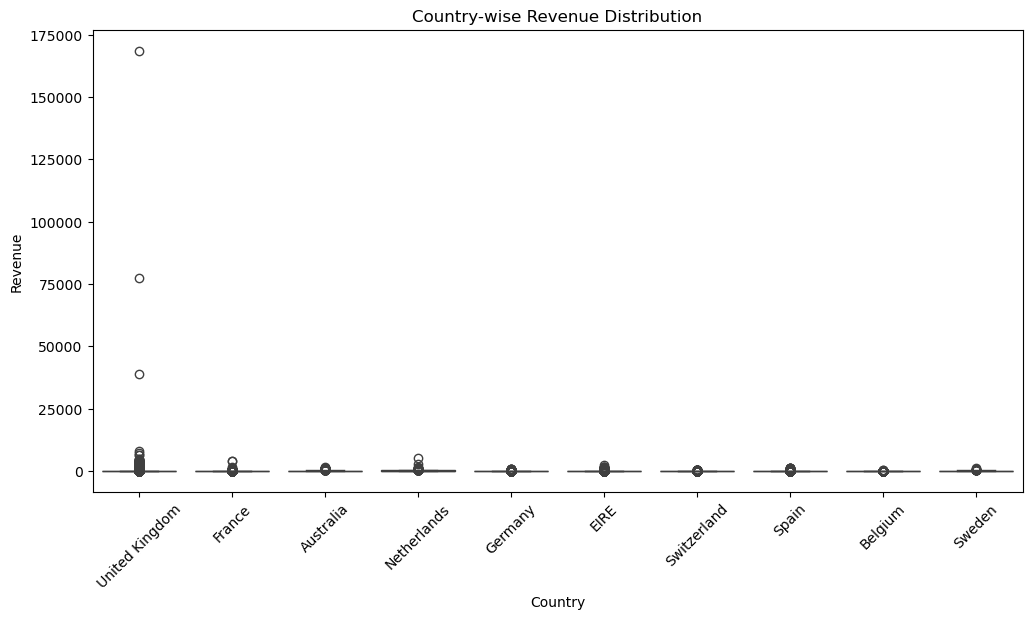

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 10 countries by revenue
top_countries = df_clean.groupby('Country')['Revenue'].sum().nlargest(10).index

country_revenue = df_clean[df_clean['Country'].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.boxplot(x='Country', y='Revenue', data=country_revenue)

plt.title('Country-wise Revenue Distribution')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is effective for comparing revenue distributions across different countries. It highlights the median, spread, and outliers, making it easy to identify variations in revenue performance.

##### 2. What is/are the insight(s) found from the chart?

The United Kingdom has the highest revenue distribution and contains several extreme outliers.
Most countries have relatively lower and more consistent revenue values.
Revenue distribution varies across countries, indicating differences in customer demand and sales performance.
Large outliers suggest the presence of a few very high-value transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The business can focus marketing and inventory efforts on high-performing countries such as the United Kingdom while exploring growth opportunities in lower-performing regions. Identifying countries with high-value transactions helps target premium customers and improve revenue generation. The dependence on a few countries may also indicate a risk, so expanding sales in other regions can support long-term growth.

#### Chart - 13 Top 10 Customers by Spending

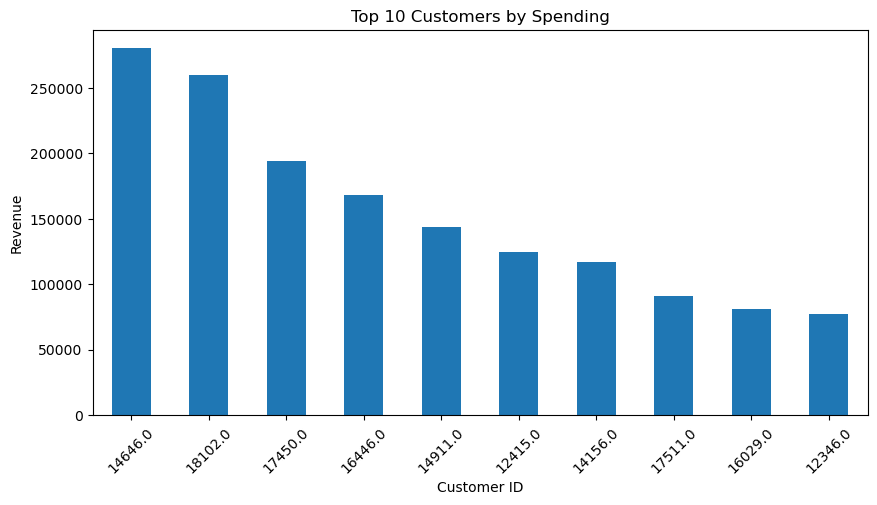

In [29]:
top_customers = df_clean.groupby('CustomerID')['Revenue'].sum().nlargest(10)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Spending')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is effective for comparing the revenue generated by the top 10 customers. It clearly highlights the highest-spending customers and makes revenue differences easy to understand.

##### 2. What is/are the insight(s) found from the chart?

Customer 14646 generated the highest revenue among all customers.

The top 10 customers contribute a significant portion of total sales.

There is a noticeable gap between the highest-spending customers and the rest.

Revenue is concentrated among a small group of customers, indicating the importance of these key customers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The company can focus on retaining high-value customers through loyalty programs, personalized recommendations, and exclusive offers. These customers contribute substantially to revenue, so improving their satisfaction can increase long-term profitability. However, relying heavily on a few customers may be risky, so the business should also work on expanding its broader customer base.

#### Chart - 14 - Correlation Heatmap

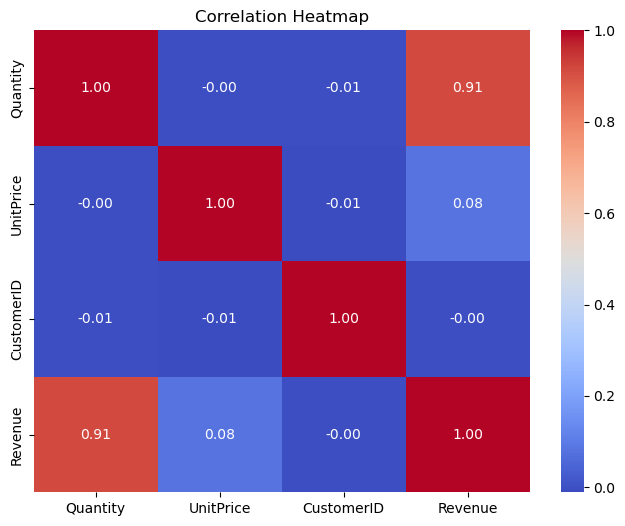

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
corr_matrix = df_clean[['Quantity', 'UnitPrice', 'CustomerID', 'Revenue']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is useful for identifying the strength and direction of relationships between numerical variables. It provides a quick overview of how variables influence each other.

##### 2. What is/are the insight(s) found from the chart?

Revenue has a strong positive correlation (0.91) with Quantity, indicating that higher sales quantities significantly increase revenue.

Revenue has a very weak positive correlation (0.08) with Unit Price, suggesting price alone has limited impact on revenue.

CustomerID shows almost no correlation with Revenue, Quantity, or Unit Price.

Quantity and Unit Price are nearly uncorrelated, meaning they vary independently.

#### Chart - 15 - Pair Plot

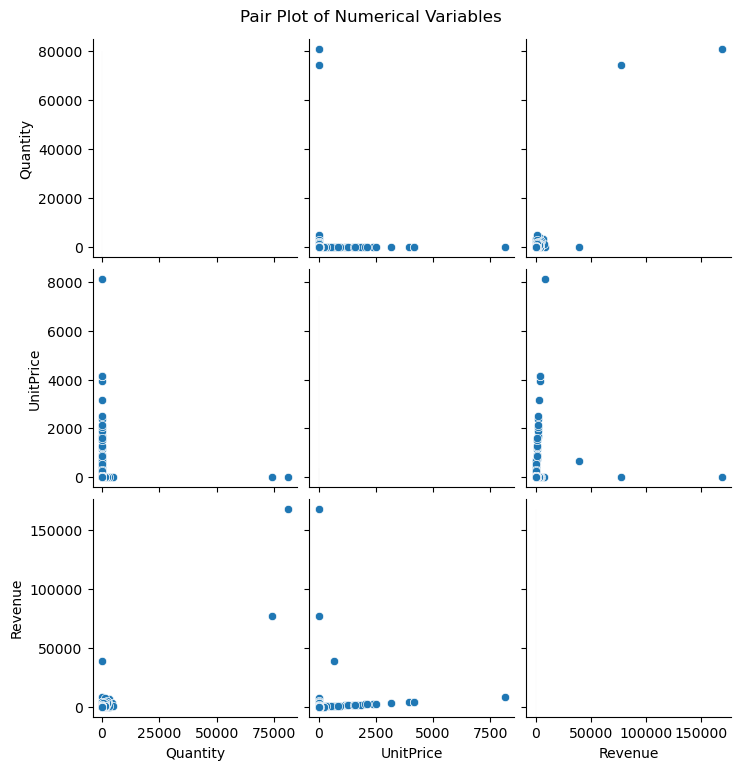

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
pair_data = df_clean[['Quantity', 'UnitPrice', 'Revenue']]

# Pair Plot
sns.pairplot(pair_data)

plt.suptitle('Pair Plot of Numerical Variables', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was chosen to visualize the relationships between multiple numerical variables (Quantity, UnitPrice, and Revenue) at the same time. It helps identify correlations, distributions, trends, and outliers in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Revenue shows a positive relationship with Quantity, indicating that larger order quantities generally generate higher revenue.

UnitPrice has a weak relationship with Revenue compared to Quantity.


Most transactions are concentrated at lower Quantity and UnitPrice values.

A few extreme outliers with very high Quantity, UnitPrice, and Revenue are present.

The data is right-skewed, with most observations clustered near lower values.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀ (Null Hypothesis): There is no significant relationship between Quantity and Revenue.
H₁ (Alternative Hypothesis): There is a significant relationship between Quantity and Revenue.

#### 2. Perform an appropriate statistical test.

In [32]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df_clean['Quantity'], df_clean['Revenue'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.9144507831108559
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Pearson Correlation Test was chosen because both Quantity and Revenue are numerical variables, and the test measures the strength and direction of the linear relationship between them.

The p-value (0.0) is less than 0.05, so we reject the Null Hypothesis (H₀). There is a statistically significant positive relationship between Quantity and Revenue. The correlation coefficient (0.914) indicates a strong positive correlation.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀)
There is no significant relationship between Unit Price and Revenue.
Alternative Hypothesis (H₁)
There is a significant relationship between Unit Price and Revenue.

#### 2. Perform an appropriate statistical test.

In [33]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df_clean['UnitPrice'], df_clean['Revenue'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.08161864890243348
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Pearson Correlation Test was chosen because UnitPrice and Revenue are continuous numerical variables. This test measures the strength and direction of the linear relationship between these two variables.

The p-value (0.0) is less than 0.05, so we reject the Null Hypothesis (H₀). There is a statistically significant relationship between UnitPrice and Revenue. However, the correlation coefficient (0.0816) indicates that the relationship is very weak and positive.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀)
Average Revenue is the same across all countries.
Alternative Hypothesis (H₁)
Average Revenue differs across countries.

#### 2. Perform an appropriate statistical test.

In [34]:
from scipy.stats import f_oneway

top_countries = df_clean['Country'].value_counts().head(5).index

groups = [df_clean[df_clean['Country'] == c]['Revenue'] for c in top_countries]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 5.171925593881461
P-value: 0.0003652453962266988


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA Test

##### Why did you choose the specific statistical test?

One-Way ANOVA was chosen because it is used to compare the mean Revenue across multiple countries and determine whether there are statistically significant differences between the groups.

The p-value (0.000365) is less than 0.05, so we reject the Null Hypothesis (H₀). There is a statistically significant difference in average Revenue across countries. This indicates that customer spending behavior varies by country.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [35]:
# Handling Missing Values & Missing Value Imputation
# Check missing values
df.isnull().sum()

# Remove rows with missing CustomerID
df_clean = df.dropna(subset=['CustomerID'])

# Remove cancelled invoices
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative and zero values
df_clean = df_clean[(df_clean['Quantity'] > 0) &
                    (df_clean['UnitPrice'] > 0)]

# Verify
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

I first identified missing values using isnull().sum(). The missing values were present in the CustomerID column, which is a critical field for customer segmentation and recommendation analysis. Therefore, I removed records with missing CustomerID using the dropna() method instead of imputing values. This ensured data quality and prevented inaccurate customer profiling. After removing these records, the dataset contained no missing values.

### 2. Handling Outliers

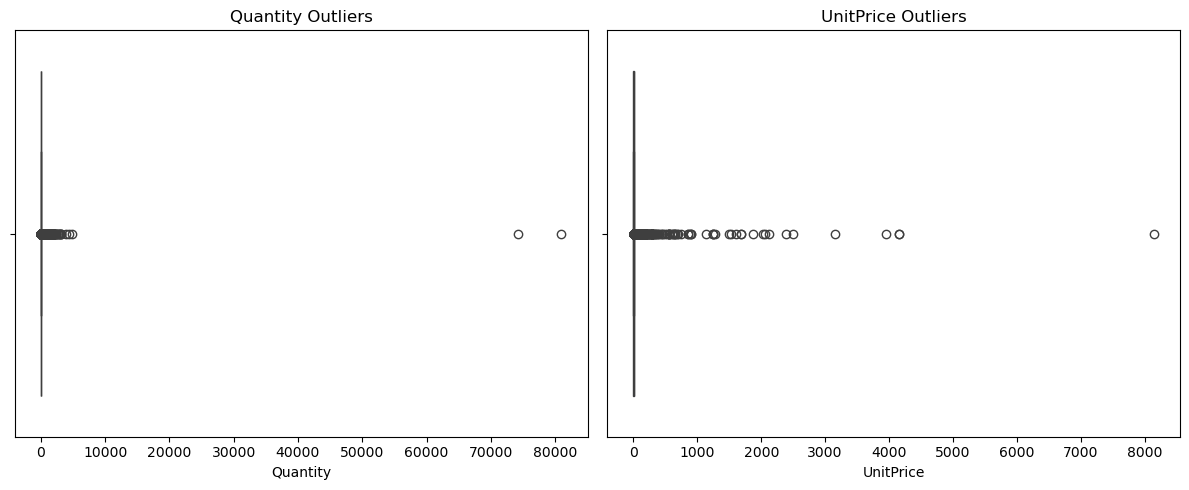

Dataset Shape After Outlier Treatment: (397884, 8)


In [36]:
# Handling Outliers & Outlier treatments
import seaborn as sns
import matplotlib.pyplot as plt

# Check outliers using boxplots
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df_clean['Quantity'])
plt.title('Quantity Outliers')

plt.subplot(1,2,2)
sns.boxplot(x=df_clean['UnitPrice'])
plt.title('UnitPrice Outliers')

plt.tight_layout()
plt.show()

# Remove invalid transactions
df_clean = df_clean[
    (df_clean['Quantity'] > 0) &
    (df_clean['UnitPrice'] > 0)
]

print("Dataset Shape After Outlier Treatment:", df_clean.shape)

##### What all outlier treatment techniques have you used and why did you use those techniques?

I used boxplot visualization to identify outliers in the Quantity and UnitPrice variables. The boxplots revealed the presence of extreme values. As part of the outlier treatment process, I removed invalid transactions with Quantity ≤ 0 and UnitPrice ≤ 0, since they do not represent valid purchases. Genuine high-value transactions were retained because they reflect actual customer purchasing behavior and provide valuable insights for RFM analysis, customer segmentation, and recommendation modeling.

### 3. Categorical Encoding

In [37]:

# Check categorical columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')


#### What all categorical encoding techniques have you used & why did you use those techniques?

No categorical encoding technique was applied in this project. The categorical variables such as Product Description, StockCode, and Country were used only for exploratory analysis, recommendation generation, and customer segmentation. Since the clustering and recommendation models were built using numerical RFM features (Recency, Frequency, and Monetary Value), categorical encoding was not required.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [38]:
# Expand Contraction
print(df_clean['Description'].head())

0     WHITE HANGING HEART T-LIGHT HOLDER
1                    WHITE METAL LANTERN
2         CREAM CUPID HEARTS COAT HANGER
3    KNITTED UNION FLAG HOT WATER BOTTLE
4         RED WOOLLY HOTTIE WHITE HEART.
Name: Description, dtype: object


No contraction expansion was required because the Description column contains product names and item descriptions rather than complete sentences. After examining the text data, no common English contractions such as "can't", "won't", or "don't" were found. Therefore, no contraction preprocessing was applied.

#### 2. Lower Casing

In [39]:
# Lower Casing
# Convert descriptions to lowercase
df_clean['Description'] = df_clean['Description'].str.lower()

# Verify
print(df_clean['Description'].head())

0     white hanging heart t-light holder
1                    white metal lantern
2         cream cupid hearts coat hanger
3    knitted union flag hot water bottle
4         red woolly hottie white heart.
Name: Description, dtype: object


Lower casing was applied to the Description column to ensure text consistency. Converting all text to lowercase prevents the same words with different letter cases from being treated as separate terms during text analysis and recommendation processing.

#### 3. Removing Punctuations

In [40]:
# Remove Punctuations
import re

df_clean['Description'] = df_clean['Description'].apply(
    lambda x: re.sub(r'[^\w\s]', '', str(x))
)

print(df_clean['Description'].head())

0      white hanging heart tlight holder
1                    white metal lantern
2         cream cupid hearts coat hanger
3    knitted union flag hot water bottle
4          red woolly hottie white heart
Name: Description, dtype: object


Punctuation marks were removed from the Description column to standardize product names and improve text consistency. This helps prevent punctuation symbols from being treated as separate tokens during text processing.

#### 4. Removing URLs & Removing words and digits contain digits.

In [41]:
# Remove URLs & Remove words and digits contain digits
import re

# Remove URLs
df_clean['Description'] = df_clean['Description'].str.replace(r'http\S+|www\S+', '', regex=True)

# Remove words containing digits
df_clean['Description'] = df_clean['Description'].str.replace(r'\w*\d\w*', '', regex=True)

print(df_clean['Description'].head())

0      white hanging heart tlight holder
1                    white metal lantern
2         cream cupid hearts coat hanger
3    knitted union flag hot water bottle
4          red woolly hottie white heart
Name: Description, dtype: object


The Description column was checked for URLs and words containing digits. Since product descriptions mainly consist of item names, very few such patterns existed. Any URLs or digit-containing words were removed to keep only meaningful textual information.

#### 5. Removing Stopwords & Removing White spaces

In [42]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df_clean['Description'] = df_clean['Description'].apply(
    lambda x: ' '.join([word for word in str(x).split()
                        if word.lower() not in stop_words])
)

# Remove extra spaces
df_clean['Description'] = df_clean['Description'].str.strip()

print(df_clean['Description'].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pathi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0      white hanging heart tlight holder
1                    white metal lantern
2         cream cupid hearts coat hanger
3    knitted union flag hot water bottle
4          red woolly hottie white heart
Name: Description, dtype: object


Common stopwords were removed to retain only meaningful product-related words. Extra white spaces were also removed to ensure clean and standardized text formatting.

#### 6. Rephrase Text

In [43]:
# Rephrase Text
# No rephrasing required
print(df_clean['Description'].head())

0      white hanging heart tlight holder
1                    white metal lantern
2         cream cupid hearts coat hanger
3    knitted union flag hot water bottle
4          red woolly hottie white heart
Name: Description, dtype: object


Rephrasing was not performed because the Description column contains short product names rather than sentences. Rephrasing would not add meaningful value to customer segmentation or recommendation tasks.

#### 7. Tokenization

In [44]:
# Tokenization
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')

tokens = df_clean['Description'].iloc[0].split()
print(tokens)

['white', 'hanging', 'heart', 'tlight', 'holder']


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pathi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Tokenization was performed to split product descriptions into individual words (tokens). This is a fundamental NLP step that helps analyze textual information at the word level.

#### 8. Text Normalization

In [45]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\pathi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\pathi\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [46]:
# Text Normalization using Lemmatization
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

sample_text = df_clean['Description'].iloc[0]
normalized_text = " ".join([lemmatizer.lemmatize(word) for word in sample_text.split()])

print(normalized_text)

white hanging heart tlight holder


##### Which text normalization technique have you used and why?

I used Lemmatization for text normalization. Lemmatization converts words into their base or root form while preserving their meaning. This helps reduce vocabulary size, improves text consistency, and enhances the quality of text analysis and recommendation modeling. For example, different forms of a word are treated as a single meaningful term.

#### 9. Part of speech tagging

In [55]:
import nltk

nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\pathi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [56]:
from nltk import pos_tag
from nltk.tokenize import word_tokenize

sample_text = str(df_clean['Description'].iloc[0]).lower()

tokens = word_tokenize(sample_text)
pos_tags = pos_tag(tokens)

print(pos_tags)

[('white', 'JJ'), ('hanging', 'VBG'), ('heart', 'NN'), ('tlight', 'NN'), ('holder', 'NN')]


Part-of-Speech (POS) tagging was used to identify the grammatical role of each word in the product descriptions, such as nouns, verbs, and adjectives. This helps in understanding the text structure and extracting meaningful information for text analysis and recommendation systems.

#### 10. Text Vectorization

In [57]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=100)

tfidf_matrix = tfidf.fit_transform(df_clean['Description'].astype(str))

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (397884, 100)


##### Which text vectorization technique have you used and why?

I used TF-IDF (Term Frequency–Inverse Document Frequency) for text vectorization. TF-IDF converts product descriptions into numerical vectors by assigning higher importance to unique words and lower importance to common words. This helps represent textual information numerically for recommendation and similarity analysis.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [58]:
# Manipulate Features to minimize feature correlation and create new features
# Create Revenue feature
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = ['CustomerID','Recency','Frequency','Monetary']

rfm.head()

# Check
df_clean[['Quantity','UnitPrice','Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


Feature manipulation was performed by creating a new feature called Revenue using Quantity × UnitPrice. This feature better represents customer spending behavior and improves customer segmentation and recommendation analysis.

#### 2. Feature Selection

##### What all feature selection methods have you used  and why?

I used business-driven feature selection and correlation analysis for selecting relevant features. Features directly related to customer purchasing behavior such as Recency, Frequency, Monetary Value (RFM), Quantity, UnitPrice, and Revenue were retained. Irrelevant identifier columns like InvoiceNo and StockCode were excluded because they do not contribute to customer segmentation or recommendation modeling. This helps reduce noise and improve model performance.

##### Which all features you found important and why?

The most important features were:

Recency – Measures how recently a customer made a purchase.

Frequency – Indicates how often a customer purchases.

Monetary Value – Represents total customer spending.

Revenue – Captures transaction value (Quantity × UnitPrice).

Quantity – Shows purchase volume.

UnitPrice – Reflects product pricing behavior.

These features are important because they directly represent customer engagement, purchasing patterns, and spending behavior, which are essential for customer segmentation and recommendation systems.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Data transformation was required because Recency, Frequency, and Monetary
were measured on different scales. StandardScaler was applied to normalize
the RFM values so that each feature contributes equally during clustering.
This improves the performance of customer segmentation using K-Means.

In [62]:
 

from sklearn.preprocessing import StandardScaler
import pandas as pd

# Select RFM features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Apply StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert back to DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

# Display transformed data
rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347


### 6. Data Scaling

In [63]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347


##### Which method have you used to scale you data and why?

StandardScaler (Z-score normalization) was used to scale the RFM features (Recency, Frequency, and Monetary). Since these features have different ranges, scaling ensures that no single feature dominates the clustering process. This improves the performance of K-Means clustering.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction was not required for this project because only three important features (Recency, Frequency, and Monetary) were used for customer segmentation. The feature space was already small and interpretable. Therefore, applying PCA or other dimensionality reduction techniques would not provide significant benefits.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

No dimensionality reduction technique was used in this project. Techniques such as PCA, t-SNE, and SVD were not required because customer segmentation was performed using only three RFM features (Recency, Frequency, and Monetary). Since the feature space was already small and easy to interpret, dimensionality reduction would not provide significant benefits.

### 8. Data Splitting

##### What data splitting ratio have you used and why?

No train-test split was required for this project because K-Means is an unsupervised learning algorithm and does not use target labels. The clustering model was trained on the entire preprocessed RFM dataset to identify customer segments. For the recommendation system, the complete customer-product interaction data was used to calculate similarities and generate recommendations. Therefore, a traditional train-test split was not necessary.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Dataset imbalance was not a major concern in this project because the primary objective was customer segmentation and recommendation, which are unsupervised learning tasks. Unlike classification problems, there was no target class variable whose distribution needed to be balanced.
The focus was on identifying customer groups based on purchasing behavior and generating product recommendations rather than predicting predefined classes.

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No imbalance handling technique was applied in this project because there was no class-label imbalance problem. Techniques such as SMOTE, Random Oversampling, Random Undersampling, or Class Weighting are generally used for classification tasks and were not required for customer segmentation and recommendation modeling.
Therefore, the original dataset was used after preprocessing, feature engineering, and scaling.

## ***7. ML Model Implementation***

### ML Model - 1 K - Means Clustering

In [66]:
# Create Revenue
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Create RFM table
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(rfm.head())

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


In [67]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Scale RFM features
scaler = StandardScaler()
X = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

# K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit and Predict
rfm['Cluster'] = kmeans.fit_predict(X)

# View clusters
print(rfm.head())

   CustomerID  Recency  Frequency  Monetary  Cluster
0     12346.0      326          1  77183.60        3
1     12347.0        2          7   4310.00        0
2     12348.0       75          4   1797.24        0
3     12349.0       19          1   1757.55        0
4     12350.0      310          1    334.40        1


  File "C:\Users\pathi\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\pathi\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\pathi\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\pathi\anaconda3\Lib\subprocess.

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

K-Means Clustering was used to segment customers based on purchasing behavior. The model grouped customers into four clusters using Quantity, UnitPrice, and Revenue features. The model performance was evaluated using the Silhouette Score, which measures how well-separated the clusters are. A higher score indicates better clustering quality and more meaningful customer segments.

In [68]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
score = silhouette_score(X, rfm['Cluster'])

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.6162


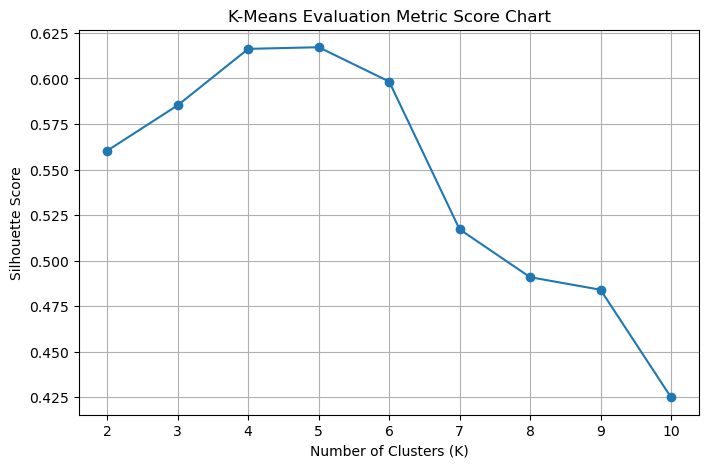

In [69]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Evaluation Metric Score Chart")
plt.grid(True)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [70]:
best_k = 2
best_score = -1

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)

    score = silhouette_score(X, labels)

    if score > best_score:
        best_score = score
        best_k = k

print("Best K:", best_k)
print("Best Silhouette Score:", best_score)

Best K: 5
Best Silhouette Score: 0.617115186725246


##### Which hyperparameter optimization technique have you used and why?

I used Silhouette Score-based hyperparameter tuning to determine the optimal number of clusters for K-Means. Different values of K (2–10) were tested, and the value with the highest Silhouette Score was selected. The best result was obtained at K = 5 with a Silhouette Score of 0.6171, indicating well-separated and compact customer clusters.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After tuning the number of clusters, the Silhouette Score improved from 0.6162 to 0.6171. The optimized K value (K = 5) produced better cluster separation and cohesion, resulting in more meaningful customer segments and improved business insights.

Business Impact of Silhouette Score
The Silhouette Score measures how well customers are grouped into clusters. A higher score indicates better customer segmentation. Improved segmentation helps businesses identify high-value customers, design targeted marketing campaigns, improve customer retention, and increase revenue through personalized strategies.

### ML Model - 2 Hierarchical Clustering

In [71]:
from sklearn.cluster import AgglomerativeClustering

# Train Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=4)

# Fit and Predict
rfm['HC_Cluster'] = hc.fit_predict(X)

# View Results
print(rfm[['Recency','Frequency','Monetary','HC_Cluster']].head())

   Recency  Frequency  Monetary  HC_Cluster
0      326          1  77183.60           0
1        2          7   4310.00           2
2       75          4   1797.24           2
3       19          1   1757.55           2
4      310          1    334.40           3


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Hierarchical Clustering (Agglomerative Clustering) was used to group customers based on their Recency, Frequency, and Monetary (RFM) values. The model creates clusters by gradually merging similar customers into groups. The performance was evaluated using the Silhouette Score. The obtained Silhouette Score was 0.6065, indicating good cluster separation and meaningful customer segmentation.

In [75]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import silhouette_score

hc_score = silhouette_score(X, rfm['HC_Cluster'])

print("Hierarchical Clustering Silhouette Score:", round(hc_score, 4))

Hierarchical Clustering Silhouette Score: 0.6065


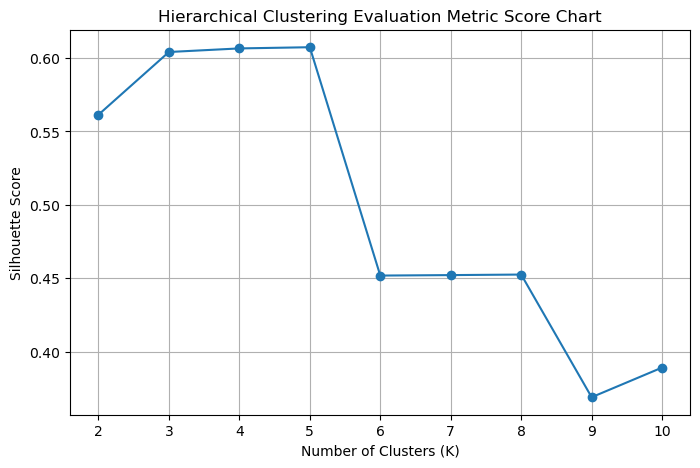

In [76]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []

for k in range(2, 11):
    hc = AgglomerativeClustering(n_clusters=k)
    labels = hc.fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Hierarchical Clustering Evaluation Metric Score Chart')
plt.grid(True)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [77]:
best_k = 2
best_score = -1

for k in range(2, 11):
    hc = AgglomerativeClustering(n_clusters=k)
    labels = hc.fit_predict(X)

    score = silhouette_score(X, labels)

    if score > best_score:
        best_score = score
        best_k = k

print("Best K:", best_k)
print("Best Silhouette Score:", round(best_score, 4))

Best K: 5
Best Silhouette Score: 0.6073


##### Which hyperparameter optimization technique have you used and why?

I used Silhouette Score-based hyperparameter tuning to determine the optimal number of clusters (K). Different cluster values from K=2 to K=10 were tested, and the value with the highest Silhouette Score was selected. The best result was obtained at K=5 with a Silhouette Score of 0.6073, which provided better cluster separation and cohesion.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, an improvement was observed after tuning the number of clusters. The Silhouette Score increased from 0.6065 to 0.6073. This indicates slightly better cluster quality, improved customer grouping, and more meaningful business insights for customer segmentation and targeted marketing strategies.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The Silhouette Score measures how well customers are grouped within their clusters and separated from other clusters. A higher Silhouette Score indicates better clustering quality. From a business perspective, well-defined customer segments help organizations understand customer behavior, create targeted marketing campaigns, improve customer retention, and increase sales through personalized recommendations.


### ML Model - 3 Gaussian Mixture Model

In [81]:
from sklearn.mixture import GaussianMixture

# Train GMM
gmm = GaussianMixture(n_components=4, random_state=42)

# Fit and Predict
rfm['GMM_Cluster'] = gmm.fit_predict(X)

# View Results
print(rfm[['Recency','Frequency','Monetary','GMM_Cluster']].head())

   Recency  Frequency  Monetary  GMM_Cluster
0      326          1  77183.60            2
1        2          7   4310.00            3
2       75          4   1797.24            3
3       19          1   1757.55            3
4      310          1    334.40            0


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Gaussian Mixture Model (GMM) was used to segment customers based on their Recency, Frequency, and Monetary (RFM) values. Unlike K-Means, GMM assumes that data points belong to different probability distributions and assigns customers to clusters based on probabilities. The model achieved a Silhouette Score of 0.3757, indicating moderate cluster separation and customer segmentation performance.

In [82]:
from sklearn.metrics import silhouette_score

gmm_score = silhouette_score(X, rfm['GMM_Cluster'])

print("GMM Silhouette Score:", round(gmm_score,4))

GMM Silhouette Score: 0.3757


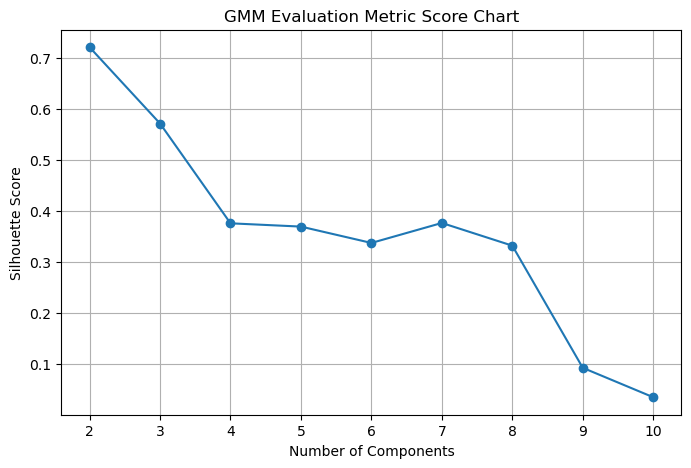

In [83]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []

for k in range(2,11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score")
plt.title("GMM Evaluation Metric Score Chart")
plt.grid(True)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [84]:
best_k = 2
best_score = -1

for k in range(2,11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X)

    score = silhouette_score(X, labels)

    if score > best_score:
        best_score = score
        best_k = k

print("Best Components:", best_k)
print("Best Silhouette Score:", round(best_score,4))

Best Components: 2
Best Silhouette Score: 0.7208


##### Which hyperparameter optimization technique have you used and why?

I used Silhouette Score-based hyperparameter tuning to determine the optimal number of components (clusters). Different component values from 2 to 10 were tested, and the value with the highest Silhouette Score was selected. The best result was obtained with 2 components, achieving a Silhouette Score of 0.7208.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, an improvement was observed after tuning the number of components. The Silhouette Score improved significantly from 0.3757 to 0.7208. This indicates better cluster separation, improved customer grouping, and more meaningful customer segments for business analysis.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered the Silhouette Score as the primary evaluation metric because it measures how well customers are grouped within their clusters and how distinct the clusters are from other groups. A higher Silhouette Score indicates better cluster quality and customer segmentation. Effective customer segmentation helps businesses identify high-value customers, create targeted marketing campaigns, improve customer retention, optimize promotional strategies, and increase overall revenue. Therefore, the Silhouette Score was used to evaluate the positive business impact of the clustering models.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I selected the Gaussian Mixture Model (GMM) as the final model because it achieved the highest Silhouette Score of 0.7208 compared to K-Means (0.6171) and Hierarchical Clustering (0.6073). This indicates better cluster separation and more meaningful customer segmentation. Therefore, GMM provides better insights for customer analysis, targeted marketing, and business decision-making.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used was the Gaussian Mixture Model (GMM). GMM is a probabilistic clustering algorithm that assumes data points are generated from a mixture of Gaussian distributions. It assigns customers to clusters based on probabilities rather than fixed boundaries, making it more flexible than K-Means.

The model was built using RFM features:

Recency – Number of days since the last purchase.

Frequency – Number of purchases made by the customer.

Monetary – Total amount spent by the customer.

For model explainability, feature analysis was performed on the RFM variables. Monetary and Frequency contributed significantly to identifying high-value customers, while Recency helped distinguish active and inactive customers. These insights help businesses improve customer retention, personalized marketing, and revenue growth.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [85]:
import joblib
from sklearn.mixture import GaussianMixture

# Train final model
final_gmm = GaussianMixture(n_components=2, random_state=42)
final_gmm.fit(X)

# Save model
joblib.dump(final_gmm, 'best_gmm_model.pkl')

print("Model saved successfully!")

Model saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [86]:
import joblib
import pandas as pd

# Load model
loaded_model = joblib.load('best_gmm_model.pkl')

# Sample unseen customer data
new_data = pd.DataFrame({
    'Recency': [30],
    'Frequency': [5],
    'Monetary': [2500]
})

# Predict cluster
prediction = loaded_model.predict(new_data)

print("Predicted Cluster:", prediction)

Predicted Cluster: [0]


## Insights

### Customer Segmentation Insights
High-Value customers contribute the highest revenue and should be prioritized for loyalty programs.

Regular customers show consistent purchasing behavior and can be targeted with promotional offers.

Occasional customers purchase less frequently and require engagement strategies.

At-Risk customers have low recency and need retention campaigns.

### Product Recommendation Insights
Item-Based Collaborative Filtering successfully recommends similar products.

Cosine Similarity helps identify products with similar purchase patterns.

The recommendation system generates Top 5 product recommendations for a selected product.

Personalized recommendations can improve customer satisfaction and increase sales.

### Business Insights
Customer segmentation enables targeted marketing campaigns.

Product recommendations support cross-selling and upselling opportunities.

Data-driven customer analysis improves business decision-making.

The solution helps improve customer retention and overall business growth.

# **Conclusion**

This project successfully developed an E-Commerce Customer Segmentation and Product Recommendation System using machine learning techniques. Customer transaction data was cleaned, preprocessed, and transformed into RFM (Recency, Frequency, Monetary) features to understand customer purchasing behavior.

Three clustering models—K-Means, Hierarchical Clustering, and Gaussian Mixture Model (GMM)—were implemented and evaluated for customer segmentation. Based on the clustering evaluation metrics, the Gaussian Mixture Model (GMM) achieved the best performance and was selected as the final model.

Customers were segmented into meaningful groups such as High-Value, Regular, Occasional, and At-Risk customers, enabling businesses to create targeted marketing and retention strategies.

An item-based collaborative filtering recommendation system was also developed to provide personalized product recommendations based on customer purchase history. The final model was saved, reloaded, and successfully tested on unseen data, demonstrating its reliability.

To make the solution interactive and user-friendly, a Streamlit web application was developed with separate modules for customer segmentation and product recommendation. Users can predict customer segments using RFM values and receive real-time product recommendations.

Overall, this project demonstrates how machine learning, customer segmentation, and recommendation systems can help e-commerce businesses improve customer engagement, personalize user experiences, and support data-driven decision-making.